In [1]:
import pandas as pd


In [7]:
df = pd.read_csv(r'C:\Users\suhas\Downloads\people_data.csv')

In [3]:
# choose a numeric column (example: Price)

data = df["Price"].dropna()

In [4]:
# mean

mean = sum(data) / len(data)

In [5]:
# standard deviation (population)

variance = sum((x - mean) ** 2 for x in data) / len(data)
std_dev = variance ** 0.5

In [6]:
# z-scores

z_scores = [(x - mean) / std_dev for x in data]

print("Mean:", mean)
print("Standard Deviation:", std_dev)

print("\nFirst 5 Z-scores:")
for i in range(5):
    print(z_scores[i])

Mean: 5016.970630372492
Standard Deviation: 2839.6457310023197

First 5 Z-scores:
0.18700549995723173
-0.6944424823291034
-0.3567242981450861
-0.07359038773429366
-1.12689079325504


In [8]:
import numpy as np

In [ ]:
np.random.seed(861)   #for reproducibility -> ensures the same random numbers are generated each time
X = np.random.randint(1, 100000, size = 5)  # generates 5 random integers between 1 and 100000
print(X)

[10425 99865 95222 18251 22689]



standardization using scikit-learn

In [16]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
X_scaled = s.fit_transform(X.reshape(-1, 1))  # Reshape to 2D array for StandardScaler
#X_scaled = s.fit_transform(-1,1)
print(X_scaled)

[[-0.98093043]
 [ 1.27646092]
 [ 1.15927545]
 [-0.78340869]
 [-0.67139725]]


In [21]:
# mean = np.mean(X)
# print(mean)

s, n = 0,0
for i in X:
    s+= i
    n = n+1
    
mean = s/n
print(mean)

49290.4


In [19]:
# sdeviation = np.std(data)
# print(sdeviation)

sq = 0
for i in X:
    sq = sq+((i - mean) ** 2)

std = (sq/len(X)) ** (1/2)
print(std)

39620.95454478602


In [20]:
X_scaled = []
for i in X:
    X_scaled.append((i - mean) / std)
print(X_scaled)

[np.float64(-0.9809304305394265), np.float64(1.276460917740697), np.float64(1.1592754522882749), np.float64(-0.7834086875649158), np.float64(-0.6713972519246296)]


Normalization

In [23]:
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler()
X_scaled = m.fit_transform(X.reshape(-1, 1))  # Reshape to 2D array for MinMaxScaler
print(X_scaled)

[[0.        ]
 [1.        ]
 [0.9480881 ]
 [0.0875    ]
 [0.13711986]]


In [24]:
min = np.min(X)
max = np.max(X)
# min, max = X[0], X[0]

# for i in X:
#     if i > max:
#         max = i
#     elif i < min:
#         min = i

print(max)
print(min)

99865
10425


In [25]:
X_scaled2 = []
for i in X:
    X_scaled2.append((i - min) / (max - min))
    
print(X_scaled2)

[np.float64(0.0), np.float64(1.0), np.float64(0.9480881037567084), np.float64(0.0875), np.float64(0.13711985688729875)]


In [26]:
x = [50, 60, 70, 80, 200]

In [27]:
min_val = X[0]
max_val = X[0]

In [28]:
for i in X:
    if i < min_val:
        min_val = i
    elif i > max_val:
        max_val = i

In [29]:
X_scaled = []
for i in X:
    X_scaled.append((i - min_val) / (max_val - min_val))
    
print(min_val)
print(max_val)
print(X_scaled)


10425
99865
[np.float64(0.0), np.float64(1.0), np.float64(0.9480881037567084), np.float64(0.0875), np.float64(0.13711985688729875)]


In [36]:
from sklearn.preprocessing import MinMaxScaler

X = ([50], [60], [80], [200])

scaler = MinMaxScaler()
nrml = scaler.fit_transform(X)

print(nrml)

[[0.        ]
 [0.06666667]
 [0.2       ]
 [1.        ]]


slope (w): 0.78
intercept (b): 0.5999999999999979


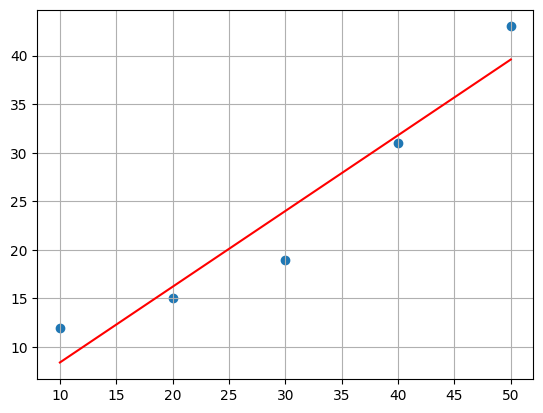

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([10 , 20, 30, 40, 50])
Y = np.array([12, 15, 19, 31, 43])

X_mean = np.mean(X)
Y_mean = np.mean(Y)

numerator = np.sum((X - X_mean) * (Y - Y_mean))
denominator = np.sum((X - X_mean) ** 2)

w = numerator / denominator
b = Y_mean - w * X_mean

#correct prediction
Y_pred = w * X + b

print("slope (w):", w)
print("intercept (b):", b)

plt.scatter(X, Y)
plt.plot(X, Y_pred, color="red")
plt.grid(True)
plt.show()